# MOVIE RATING PREDICTION WITH PYTHON

## 1) Imports & Config

In [1]:
import re
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDRegressor  # fast ridge-like linear model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For consistent results
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Path to your data
DATA_PATH = "IMDb Movies India.csv"  # adjust if needed


## 2) Load & Quick Peek

In [2]:
# Some CSVs use latin-1; fallback helps avoid Unicode errors
df = pd.read_csv(DATA_PATH, encoding="latin-1")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nMissing values (first 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

df.head(5)


Shape: (15509, 10)
Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Missing values (first 10):
Duration    8269
Rating      7590
Votes       7589
Actor 3     3144
Actor 2     2384
Genre       1877
Actor 1     1617
Year         528
Director     525
Name           0
dtype: int64


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 3) Helper Functions for Cleaning

In [3]:
def extract_first_int(text):
    """Extract first 4-digit year from strings like '(2019)'."""
    if pd.isna(text):
        return np.nan
    m = re.search(r"\d{4}", str(text))
    return int(m.group(0)) if m else np.nan

def extract_minutes(text):
    """
    Parse duration:
    - '153 min' -> 153
    - '2 h 10 min' -> 130
    - '(153 min)' -> 153
    Fallback to first number if present.
    """
    if pd.isna(text): 
        return np.nan
    s = str(text)
    # '153 min'
    m = re.search(r"(\d+)\s*min", s)
    if m:
        return int(m.group(1))
    # '2 h 10 min'
    h = re.search(r"(\d+)\s*h", s)
    mm = re.search(r"(\d+)\s*min", s)
    if h and mm:
        return int(h.group(1)) * 60 + int(mm.group(1))
    if h:
        return int(h.group(1)) * 60
    # fallback: any number
    anynum = re.search(r"(\d+)", s)
    return int(anynum.group(1)) if anynum else np.nan

def extract_votes(text):
    """Remove non-digits to get integer votes from '12,345' or '(12,345)'."""
    if pd.isna(text):
        return np.nan
    s = re.sub(r"[^\d]", "", str(text))
    return int(s) if s.isdigit() else np.nan

def split_genres(text):
    """'(Drama, Romance)' -> ['Drama', 'Romance']"""
    if pd.isna(text):
        return []
    inside = re.sub(r"^\(|\)$", "", str(text)).strip()
    parts = [p.strip() for p in inside.split(",") if p.strip()]
    return parts


## 4) Clean Columns & Engineer Features

In [4]:
df["Year_num"]     = df["Year"].apply(extract_first_int)
df["Duration_min"] = df["Duration"].apply(extract_minutes)
df["Votes_num"]    = df["Votes"].apply(extract_votes)
df["Genres_list"]  = df["Genre"].apply(split_genres)

# Keep supervised rows (must have target)
data = df[df["Rating"].notna()].copy()
y = data["Rating"].astype(float)

# Multi-hot encode genres
mlb = MultiLabelBinarizer()
genre_ohe = mlb.fit_transform(data["Genres_list"])
genre_cols = [f"Genre_{g}" for g in mlb.classes_]
genre_df = pd.DataFrame(genre_ohe, columns=genre_cols, index=data.index)

# Basic numeric/cat columns
numeric_cols = ["Year_num", "Duration_min", "Votes_num"]
for c in numeric_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")

cat_cols = ["Director", "Actor 1", "Actor 2", "Actor 3"]

# Combine final feature matrix
X = pd.concat([data[numeric_cols], genre_df, data[cat_cols]], axis=1)

print("Final X shape:", X.shape, "| y:", y.shape)
X.head(3)


Final X shape: (7919, 29) | y: (7919,)


,Year_num,Duration_min,Votes_num,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Documentary,...,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Genre_Western,Director,Actor 1,Actor 2,Actor 3
1,2019.0,109.0,8.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,2019.0,110.0,35.0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,1997.0,147.0,827.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor


## 5) Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)


## 6) Preprocessing Pipelines

In [7]:
# Numeric: impute median + scale
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# High-cardinality categoricals: one-hot (sparse)
cat_pipe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# ColumnTransformer: keep our genre dummy columns via remainder='passthrough'
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="passthrough",
    sparse_threshold=1.0  # keep sparse matrices
)


## 7) Model: Ridge-like Linear with SGDRegressor

In [19]:
model = SGDRegressor(
    loss="squared_error",
    penalty="l2",          # ridge-like
    alpha=1e-4,            # you can tune this later
    max_iter=1500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=RANDOM_STATE
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)


C:\Users\sneha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   sparse_threshold=1.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year_num', 'Duration_min',
                                                   'Votes_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Director', 'Actor 1',
                                                   'Actor 2', 'Actor 3'])])),
                ('model',
                 SGDRegressor(early_stopping=True, max_iter=1500,
                              random_state=42))])

## 8) Evaluate

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

def evaluate(pipe, X_tr, y_tr, X_te, y_te):
    pred_tr = pipe.predict(X_tr)
    pred_te = pipe.predict(X_te)

    results = {
        "train_mae":  mean_absolute_error(y_tr, pred_tr),
        "train_rmse": mean_squared_error(y_tr, pred_tr) ** 0.5,
        "train_r2":   r2_score(y_tr, pred_tr),
        "test_mae":   mean_absolute_error(y_te, pred_te),
        "test_rmse":  mean_squared_error(y_te, pred_te) ** 0.5,
        "test_r2":    r2_score(y_te, pred_te),
    }
    return pd.DataFrame([results])

# Run evaluation
eval_df = evaluate(pipe, X_train, y_train, X_test, y_test)
print(eval_df)



   train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
0   0.844287    1.064366  0.410264  1.212729   1.521304 -0.244855


## 9) Quick Diagnostics

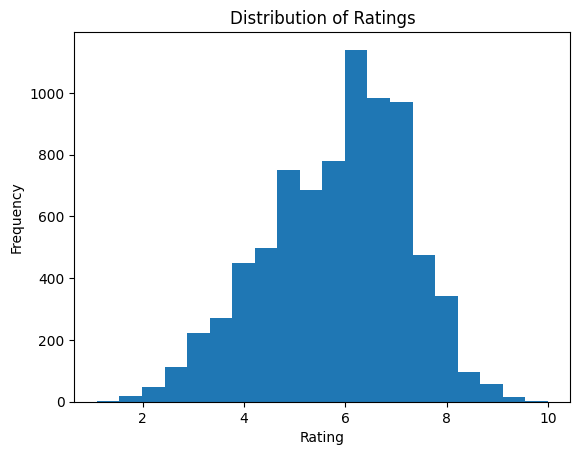

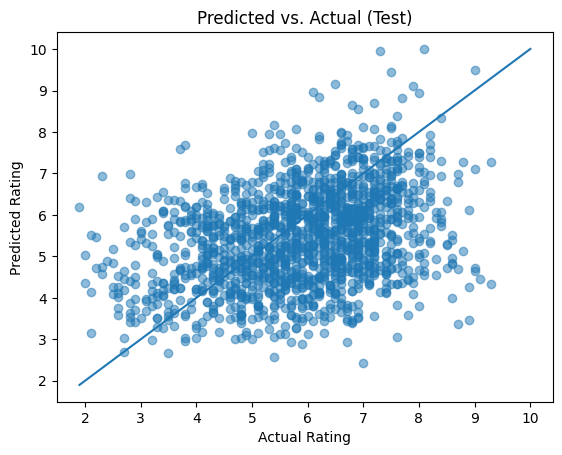

In [11]:
# Distribution of ratings
plt.figure()
plt.hist(y, bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# Predicted vs Actual (test)
pred_test = pipe.predict(X_test)
plt.figure()
plt.scatter(y_test, pred_test, alpha=0.5)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lims, lims)  # 45-degree line
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs. Actual (Test)")
plt.show()


## 10) Interpretability: Top Coefficients

In [12]:
# Build feature names in the same order they enter the linear model
num_names = [f"num__{c}" for c in numeric_cols]
cat_feature_names = pipe.named_steps["preprocess"] \
    .named_transformers_["cat"].get_feature_names_out(cat_cols)
remainder_names = genre_cols  # they were passed through unchanged

feature_names = np.concatenate([num_names, cat_feature_names, remainder_names])
coefs = np.asarray(pipe.named_steps["model"].coef_).ravel()

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
top20 = coef_df.sort_values("abs_coef", ascending=False).head(20).drop(columns=["abs_coef"])
top20


,feature,coef
9983,Genre_Documentary,2.690282
9976,Actor 3_nan,1.587232
9984,Genre_Drama,1.584512
550,Director_Debaki Bose,1.511812
2218,Director_Shantaram Rajaram Vankudre,1.500439
3826,Actor 1_Mohan Babu,1.457532
3400,Actor 1_Himesh Reshammiya,-1.453730
9980,Genre_Biography,1.430432
9979,Genre_Animation,1.409103
7142,Actor 2_Tannishtha Chatterjee,1.383434


## 11) Save Model (Pipeline) & Reload

In [13]:
MODEL_PATH = "movie_rating_model.joblib"
joblib.dump(pipe, MODEL_PATH)
print(f"Saved: {MODEL_PATH}")

# Example reload
loaded = joblib.load(MODEL_PATH)
print("Reloaded pipeline ready:", isinstance(loaded, Pipeline))


Saved: movie_rating_model.joblib
Reloaded pipeline ready: True


## 12) Predict for a New Movie

In [14]:
# Template row uses the exact columns the pipeline expects at inference time:
# - numeric_cols (Year_num, Duration_min, Votes_num)
# - genre_cols (Genre_Action, ...)
# - cat_cols (Director, Actor 1, Actor 2, Actor 3)

row = {
    "Year_num": 2020,
    "Duration_min": 130,
    "Votes_num": 50000,
    "Director": "Sanjay Leela Bhansali",
    "Actor 1": "Ranveer Singh",
    "Actor 2": "Deepika Padukone",
    "Actor 3": "Priyanka Chopra",
}

# initialize all genres to 0
for g in genre_cols:
    row[g] = 0

# set the genres for this sample
for g in ["Genre_Drama", "Genre_Romance"]:
    if g in row:
        row[g] = 1

X_new = pd.DataFrame([row])
pred = pipe.predict(X_new)[0]
print(f"Predicted rating: {pred:.2f}")


Predicted rating: 6.18


## 13) Optional: Quick Alpha Tuning

In [15]:
alphas = [1e-5, 1e-4, 1e-3, 1e-2]
scores = []

for a in alphas:
    m = SGDRegressor(
        loss="squared_error", penalty="l2", alpha=a,
        max_iter=1500, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=5, random_state=RANDOM_STATE
    )
    p = Pipeline([("preprocess", preprocess), ("model", m)])
    p.fit(X_train, y_train)
    preds = p.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    scores.append((a, mae))

pd.DataFrame(scores, columns=["alpha", "test_mae"]).sort_values("test_mae")


,alpha,test_mae
0,0.00001,1.212363
1,0.00010,1.212729
2,0.00100,1.589262
3,0.01000,1.894410
